# 10 — Refino do Gap de Sequência com Janela 24h/8h

## Objetivo

Refinar o limite de separação de sequências em torno de 900 segundos, usando a configuração temporal
mais promissora do notebook 09:

- observação: 24 horas;
- horizonte: 8 horas;
- modelo base: Random Forest com agregados + top 200 `Id_Alarme`;
- limpeza e split congelados.

## Por que agora

O gap define o que é um episódio. Como 900s foi escolhido na validação, mas a busca anterior saltou de
300s para 900s e depois para 3600s, vale testar uma faixa intermediária antes de avançar para modelos
mais complexos ou novos conceitos.

## Regra de decisão

- escolher o gap por validação, priorizando F2 e depois precisão;
- usar o teste apenas para reportar o desempenho da escolha;
- se os resultados forem muito próximos, preferir configuração mais simples e estável.

In [1]:
from pathlib import Path
import time

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, f1_score, fbeta_score,
    precision_score, recall_score, roc_auc_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 200)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")

TOP_ALARM_IDS = 200
OBSERVATION_HOURS = 24
HORIZON_HOURS = 8
GAP_CANDIDATES_SECONDS = [450, 600, 750, 900, 1200, 1500, 1800, 2400]

LOOP_TAG = "PE3798"
LOOP_DAY = pd.Timestamp("2025-06-29")
LOOP_ALARM_IDS = (1241582851, 1241582848)
MISSING_START = pd.Timestamp("2025-05-31 00:00:00")
MISSING_END = pd.Timestamp("2025-06-01 00:00:00")

con = duckdb.connect()
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")

def query(sql):
    return con.sql(sql).df()

print(f"Raiz do projeto: {ROOT}")
print(f"Gaps avaliados: {GAP_CANDIDATES_SECONDS}")
print(f"Janela fixa: {OBSERVATION_HOURS}h/{HORIZON_HOURS}h")

Raiz do projeto: /home/f_szekut/projects/vale_correct
Gaps avaliados: [450, 600, 750, 900, 1200, 1500, 1800, 2400]
Janela fixa: 24h/8h


## 1. Camada analítica congelada

Repete a limpeza aprovada e não altera arquivos brutos.

In [2]:
start = time.time()
con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE analytic_events AS
    SELECT
        min(Id_Eventos_Telemetria) AS Id_Eventos_Telemetria_referencia,
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go,
        count(*) AS ids_evento_no_grupo
    FROM tel
    WHERE NOT (
        TAG = '{LOOP_TAG}'
        AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
        AND Id_Alarme IN {LOOP_ALARM_IDS}
    )
    GROUP BY
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go
    '''
)

base_audit = query(
    '''
    SELECT
        count(*) AS registros_analiticos,
        sum(ids_evento_no_grupo - 1) AS duplicatas_retiradas,
        sum(Is_Dont_Go) AS linhas_dont_go
    FROM analytic_events
    '''
)
base_audit["tempo_s"] = round(time.time() - start, 1)
display(base_audit)

,registros_analiticos,duplicatas_retiradas,linhas_dont_go,tempo_s
0,35608094,265564.0,19941.0,16.7


## 2. Funções reutilizáveis

In [3]:
def build_sequences(gap_seconds):
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE alarm_sequences AS
        WITH ordered AS (
            SELECT *,
                   lag(Data_Evento) OVER (
                       PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                   ) AS evento_anterior
            FROM analytic_events
        ), flagged AS (
            SELECT *,
                   CASE
                       WHEN evento_anterior IS NULL THEN 1
                       WHEN date_diff('millisecond', evento_anterior, Data_Evento)
                            > {gap_seconds * 1000} THEN 1
                       ELSE 0
                   END AS nova_sequencia
            FROM ordered
        ), numbered AS (
            SELECT *,
                   sum(nova_sequencia) OVER (
                       PARTITION BY TAG, Id_Alarme
                       ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                       ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
                   ) AS numero_sequencia
            FROM flagged
        )
        SELECT
            TAG, any_value(Tag_Frota) AS Tag_Frota, any_value(Tipo) AS Tipo,
            Id_Alarme, any_value(Alarme) AS Alarme,
            numero_sequencia,
            min(Data_Evento) AS inicio,
            max(Data_Evento) AS fim,
            date_diff('millisecond', min(Data_Evento), max(Data_Evento)) AS duracao_ms,
            count(*) AS registros_analiticos,
            sum(ids_evento_no_grupo) AS registros_brutos_representados,
            max(Is_Dont_Go) AS is_dont_go,
            max(CASE WHEN Id_Criticidade = 1 THEN 1 ELSE 0 END) AS possui_critico,
            max(CASE WHEN Classe = 'Activate' THEN 1 ELSE 0 END) AS possui_activate,
            max(CASE WHEN Classe = 'Inactive' THEN 1 ELSE 0 END) AS possui_inactive,
            max(CASE WHEN Classe IS NULL THEN 1 ELSE 0 END) AS possui_classe_nula
        FROM numbered
        GROUP BY TAG, Id_Alarme, numero_sequencia
        '''
    )
    return query(
        '''
        SELECT
            count(*) AS sequencias,
            sum(is_dont_go) AS sequencias_dont_go,
            avg(registros_analiticos) AS registros_por_sequencia_media,
            max(registros_analiticos) AS maior_sequencia
        FROM alarm_sequences
        '''
    )

def build_samples():
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE sample_grid AS
        WITH tags AS (
            SELECT DISTINCT TAG FROM analytic_events
        ), prediction_bins AS (
            SELECT * FROM generate_series(
                TIMESTAMP '2025-01-01 00:00:00' + INTERVAL '{OBSERVATION_HOURS} hours',
                TIMESTAMP '2025-07-01 00:00:00' - INTERVAL '{HORIZON_HOURS} hours',
                INTERVAL '8 hours'
            ) AS t(prediction_time)
        )
        SELECT
            row_number() OVER () AS sample_id,
            tags.TAG,
            prediction_time - INTERVAL '{OBSERVATION_HOURS} hours' AS feature_start,
            prediction_time,
            prediction_time + INTERVAL '{HORIZON_HOURS} hours' AS target_end
        FROM tags CROSS JOIN prediction_bins
        WHERE prediction_time - INTERVAL '{OBSERVATION_HOURS} hours' >= TIMESTAMP '2025-01-01 00:00:00'
        '''
    )

    samples = query(
        f'''
        WITH feature_agg AS (
            SELECT
                g.sample_id,
                count(s.inicio) AS sequencias_total,
                count(DISTINCT s.Id_Alarme) AS alarmes_distintos,
                coalesce(sum(s.registros_analiticos), 0) AS registros_analiticos,
                coalesce(sum(s.registros_brutos_representados), 0) AS registros_brutos_representados,
                coalesce(avg(s.duracao_ms), 0) AS duracao_media_ms,
                coalesce(max(s.duracao_ms), 0) AS duracao_max_ms,
                coalesce(max(s.registros_analiticos), 0) AS maior_sequencia_registros,
                coalesce(sum(s.possui_critico), 0) AS sequencias_com_critico,
                coalesce(sum(s.possui_activate), 0) AS sequencias_com_activate,
                coalesce(sum(s.possui_inactive), 0) AS sequencias_com_inactive,
                coalesce(sum(s.possui_classe_nula), 0) AS sequencias_com_classe_nula
            FROM sample_grid g
            LEFT JOIN alarm_sequences s
              ON s.TAG = g.TAG
             AND s.inicio >= g.feature_start
             AND s.inicio < g.prediction_time
            GROUP BY 1
        ), target_agg AS (
            SELECT
                g.sample_id,
                coalesce(sum(s.is_dont_go), 0) AS episodios_dont_go_target
            FROM sample_grid g
            LEFT JOIN alarm_sequences s
              ON s.TAG = g.TAG
             AND s.inicio >= g.prediction_time
             AND s.inicio < g.target_end
            GROUP BY 1
        )
        SELECT
            g.TAG, g.feature_start, g.prediction_time, g.target_end,
            f.* EXCLUDE(sample_id),
            y.episodios_dont_go_target,
            CASE WHEN y.episodios_dont_go_target > 0 THEN 1 ELSE 0 END AS target,
            CASE
                WHEN g.feature_start < TIMESTAMP '{MISSING_END}'
                 AND g.target_end > TIMESTAMP '{MISSING_START}'
                THEN 0 ELSE 1
            END AS amostra_valida
        FROM sample_grid g
        JOIN feature_agg f USING(sample_id)
        JOIN target_agg y USING(sample_id)
        ORDER BY g.prediction_time, g.TAG
        '''
    )
    samples = samples[samples["amostra_valida"] == 1].copy()
    tag_profile = query(
        '''
        SELECT TAG, any_value(Tipo) AS Tipo, any_value(Tag_Frota) AS Tag_Frota
        FROM analytic_events
        GROUP BY 1
        '''
    )
    samples = samples.merge(tag_profile, how="left", on="TAG")
    samples = samples.assign(split=np.select(
        [
            samples["prediction_time"] < pd.Timestamp("2025-05-01"),
            samples["prediction_time"] < pd.Timestamp("2025-05-31"),
            samples["prediction_time"] >= pd.Timestamp("2025-06-01"),
        ],
        ["treino", "validacao", "teste"],
        default="fora_do_split",
    ))
    return samples[samples["split"].isin(["treino", "validacao", "teste"])].copy()

def add_alarm_features(samples):
    top_alarm_ids = query(
        f'''
        SELECT Id_Alarme, count(*) AS sequencias
        FROM alarm_sequences
        WHERE inicio < TIMESTAMP '2025-05-01 00:00:00'
        GROUP BY 1
        ORDER BY sequencias DESC, Id_Alarme
        LIMIT {TOP_ALARM_IDS}
        '''
    )
    alarm_ids = top_alarm_ids["Id_Alarme"].astype(int).tolist()
    alarm_columns = ",\n".join(
        f"sum(CASE WHEN s.Id_Alarme = {alarm_id} THEN 1 ELSE 0 END) AS alarm_{alarm_id}"
        for alarm_id in alarm_ids
    )
    alarm_features = query(
        f'''
        SELECT g.TAG, g.feature_start,
               {alarm_columns}
        FROM sample_grid g
        LEFT JOIN alarm_sequences s
          ON s.TAG = g.TAG
         AND s.inicio >= g.feature_start
         AND s.inicio < g.prediction_time
        GROUP BY 1, 2
        '''
    )
    samples = samples.merge(alarm_features, how="left", on=["TAG", "feature_start"])
    alarm_feature_names = [f"alarm_{alarm_id}" for alarm_id in alarm_ids]
    samples[alarm_feature_names] = samples[alarm_feature_names].fillna(0).astype("int32")
    return samples, alarm_feature_names

def prepare_features(samples, alarm_feature_names):
    samples = pd.concat([
        samples,
        pd.DataFrame({
            "feature_has_events": (samples["sequencias_total"] > 0).astype("int8"),
            "prediction_hour_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.hour / 24),
            "prediction_hour_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.hour / 24),
            "prediction_dow_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
            "prediction_dow_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
        }, index=samples.index)
    ], axis=1).copy()
    base_feature_columns = [
        "sequencias_total", "alarmes_distintos", "registros_analiticos",
        "registros_brutos_representados", "duracao_media_ms", "duracao_max_ms",
        "maior_sequencia_registros", "sequencias_com_critico",
        "sequencias_com_activate", "sequencias_com_inactive",
        "sequencias_com_classe_nula", "feature_has_events",
        "prediction_hour_sin", "prediction_hour_cos",
        "prediction_dow_sin", "prediction_dow_cos",
    ]
    return samples, base_feature_columns + alarm_feature_names

def select_threshold(y_true, probability):
    rows = []
    for threshold in np.linspace(0.01, 0.99, 197):
        pred = probability >= threshold
        rows.append({
            "threshold": threshold,
            "f2": fbeta_score(y_true, pred, beta=2, zero_division=0),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
        })
    scores = pd.DataFrame(rows)
    best = scores.sort_values(["f2", "precision", "threshold"], ascending=[False, False, False]).iloc[0]
    return float(best["threshold"])

def metric_row(experiment, split, y_true, probability, threshold, extra):
    pred = (probability >= threshold).astype(int)
    row = {
        "experimento": experiment,
        "split": split,
        "threshold": threshold,
        "amostras": len(y_true),
        "positivas": int(y_true.sum()),
        "pr_auc": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "f2": fbeta_score(y_true, pred, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "predicoes_positivas": int(pred.sum()),
        "TP": int(((y_true == 1) & (pred == 1)).sum()),
        "FP": int(((y_true == 0) & (pred == 1)).sum()),
        "FN": int(((y_true == 1) & (pred == 0)).sum()),
        "TN": int(((y_true == 0) & (pred == 0)).sum()),
    }
    row.update(extra)
    return row

def fit_evaluate(samples, feature_columns, experiment, extra):
    train = samples[samples["split"] == "treino"]
    val = samples[samples["split"] == "validacao"]
    test = samples[samples["split"] == "teste"]
    model = RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(train[feature_columns].astype("float32"), train["target"].astype("int8"))
    val_prob = model.predict_proba(val[feature_columns].astype("float32"))[:, 1]
    threshold = select_threshold(val["target"].astype("int8"), val_prob)
    test_prob = model.predict_proba(test[feature_columns].astype("float32"))[:, 1]
    return pd.DataFrame([
        metric_row(experiment, "validacao", val["target"].astype("int8"), val_prob, threshold, extra),
        metric_row(experiment, "teste", test["target"].astype("int8"), test_prob, threshold, extra),
    ])

def run_gap(gap_seconds):
    seq_audit = build_sequences(gap_seconds)
    samples = build_samples()
    samples, alarm_feature_names = add_alarm_features(samples)
    samples, feature_columns = prepare_features(samples, alarm_feature_names)
    split_audit = (
        samples.groupby(["split", "Tipo"], dropna=False)
        .agg(amostras=("target", "size"), positivas=("target", "sum"), prevalencia=("target", "mean"))
        .reset_index()
    )
    metrics = fit_evaluate(
        samples,
        feature_columns,
        f"gap_{gap_seconds}s_24h_8h",
        {
            "gap_s": gap_seconds,
            "sequencias": int(seq_audit.loc[0, "sequencias"]),
            "sequencias_dont_go": int(seq_audit.loc[0, "sequencias_dont_go"]),
            "features": len(feature_columns),
        },
    )
    return metrics, seq_audit, split_audit

## 3. Execução da busca fina

In [4]:
all_metrics = []
all_seq_audits = []
all_split_audits = []

for gap in GAP_CANDIDATES_SECONDS:
    print(f"Executando gap={gap}s com janela 24h/8h")
    start = time.time()
    metrics, seq_audit, split_audit = run_gap(gap)
    metrics["tempo_s"] = round(time.time() - start, 1)
    seq_audit["gap_s"] = gap
    split_audit["gap_s"] = gap
    all_metrics.append(metrics)
    all_seq_audits.append(seq_audit)
    all_split_audits.append(split_audit)

metrics = pd.concat(all_metrics, ignore_index=True)
seq_audits = pd.concat(all_seq_audits, ignore_index=True)
split_audits = pd.concat(all_split_audits, ignore_index=True)

display(seq_audits)
display(split_audits)
display(metrics.sort_values(["split", "f2"], ascending=[True, False]))

Executando gap=450s com janela 24h/8h
Executando gap=600s com janela 24h/8h
Executando gap=750s com janela 24h/8h
Executando gap=900s com janela 24h/8h
Executando gap=1200s com janela 24h/8h
Executando gap=1500s com janela 24h/8h
Executando gap=1800s com janela 24h/8h
Executando gap=2400s com janela 24h/8h


,sequencias,sequencias_dont_go,registros_por_sequencia_media,maior_sequencia,gap_s
0,2329467,8950.0,15.285941,32607,450
1,2225863,8370.0,15.997433,32607,600
2,1042516,7947.0,34.155921,32607,750
3,979994,7572.0,36.335012,32721,900
4,887389,6934.0,40.126815,51541,1200
5,809072,6429.0,44.011032,51541,1500
6,738664,5991.0,48.206077,57291,1800
7,599400,5385.0,59.406230,101672,2400


,split,Tipo,amostras,positivas,prevalencia,gap_s
0,teste,Caminhao,2610,284,0.108812,450
1,teste,Escavadeira,435,2,0.004598,450
2,treino,Caminhao,10710,1895,0.176937,450
3,treino,Escavadeira,1785,15,0.008403,450
4,validacao,Caminhao,2700,280,0.103704,450
5,validacao,Escavadeira,450,7,0.015556,450
6,teste,Caminhao,2610,284,0.108812,600
7,teste,Escavadeira,435,2,0.004598,600
8,treino,Caminhao,10710,1896,0.177031,600
9,treino,Escavadeira,1785,15,0.008403,600


,experimento,split,threshold,amostras,positivas,pr_auc,roc_auc,precision,recall,f1,f2,balanced_accuracy,predicoes_positivas,TP,FP,FN,TN,gap_s,sequencias,sequencias_dont_go,features,tempo_s
3,gap_600s_24h_8h,teste,0.170,3045,286,0.334452,0.826767,0.199836,0.853147,0.323822,0.515856,0.749517,1221,244,977,42,1782,600,2225863,8370,216,78.3
7,gap_900s_24h_8h,teste,0.180,3045,285,0.347722,0.820763,0.204545,0.821053,0.327502,0.512259,0.745671,1144,234,910,51,1850,900,979994,7572,216,75.3
9,gap_1200s_24h_8h,teste,0.160,3045,285,0.339609,0.825767,0.195044,0.856140,0.317708,0.510247,0.745643,1251,244,1007,41,1753,1200,887389,6934,216,75.3
11,gap_1500s_24h_8h,teste,0.150,3045,282,0.327954,0.822435,0.185768,0.879433,0.306741,0.503451,0.743010,1335,248,1087,34,1676,1500,809072,6429,216,78.3
13,gap_1800s_24h_8h,teste,0.165,3045,282,0.328365,0.819548,0.195306,0.826241,0.315932,0.501939,0.739396,1193,233,960,49,1803,1800,738664,5991,216,74.0
1,gap_450s_24h_8h,teste,0.175,3045,286,0.335134,0.826979,0.193786,0.828671,0.314115,0.500634,0.735648,1223,237,986,49,1773,450,2329467,8950,216,87.8
5,gap_750s_24h_8h,teste,0.155,3045,286,0.345747,0.820530,0.181951,0.874126,0.301205,0.496426,0.733366,1374,250,1124,36,1635,750,1042516,7947,216,74.9
15,gap_2400s_24h_8h,teste,0.125,3045,276,0.305129,0.812760,0.165782,0.905797,0.280269,0.478560,0.725741,1508,250,1258,26,1511,2400,599400,5385,216,74.2
0,gap_450s_24h_8h,validacao,0.175,3150,287,0.310248,0.800068,0.195804,0.780488,0.313068,0.488656,0.729573,1144,224,920,63,1943,450,2329467,8950,216,87.8
10,gap_1500s_24h_8h,validacao,0.150,3150,287,0.299795,0.794020,0.181682,0.843206,0.298950,0.487903,0.731243,1332,242,1090,45,1773,1500,809072,6429,216,78.3


## 4. Escolha por validação e leitura no teste

,gap_s,threshold,positivas,pr_auc,precision,recall,f2,TP,FP,FN,TN,tempo_s
0,450,0.175,287,0.310248,0.195804,0.780488,0.488656,224,920,63,1943,87.8
10,1500,0.150,287,0.299795,0.181682,0.843206,0.487903,242,1090,45,1773,78.3
2,600,0.170,287,0.305722,0.193745,0.777003,0.484993,223,928,64,1935,78.3
8,1200,0.160,287,0.292630,0.183591,0.787456,0.474989,226,1005,61,1858,75.3
12,1800,0.165,286,0.287605,0.184385,0.776224,0.472743,222,982,64,1882,74.0
6,900,0.180,287,0.286537,0.193578,0.735192,0.471403,211,879,76,1984,75.3
4,750,0.155,287,0.288701,0.177881,0.801394,0.471118,230,1063,57,1800,74.9
14,2400,0.125,281,0.265497,0.158638,0.879004,0.460649,247,1310,34,1559,74.2


,gap_s,threshold,positivas,pr_auc,precision,recall,f2,TP,FP,FN,TN,tempo_s
3,600,0.170,286,0.334452,0.199836,0.853147,0.515856,244,977,42,1782,78.3
7,900,0.180,285,0.347722,0.204545,0.821053,0.512259,234,910,51,1850,75.3
9,1200,0.160,285,0.339609,0.195044,0.856140,0.510247,244,1007,41,1753,75.3
11,1500,0.150,282,0.327954,0.185768,0.879433,0.503451,248,1087,34,1676,78.3
13,1800,0.165,282,0.328365,0.195306,0.826241,0.501939,233,960,49,1803,74.0
1,450,0.175,286,0.335134,0.193786,0.828671,0.500634,237,986,49,1773,87.8
5,750,0.155,286,0.345747,0.181951,0.874126,0.496426,250,1124,36,1635,74.9
15,2400,0.125,276,0.305129,0.165782,0.905797,0.478560,250,1258,26,1511,74.2


Gap escolhido pela validação: 450s
Resultado correspondente no teste:


,experimento,split,threshold,amostras,positivas,pr_auc,roc_auc,precision,recall,f1,f2,balanced_accuracy,predicoes_positivas,TP,FP,FN,TN,gap_s,sequencias,sequencias_dont_go,features,tempo_s
1,gap_450s_24h_8h,teste,0.175,3045,286,0.335134,0.826979,0.193786,0.828671,0.314115,0.500634,0.735648,1223,237,986,49,1773,450,2329467,8950,216,87.8


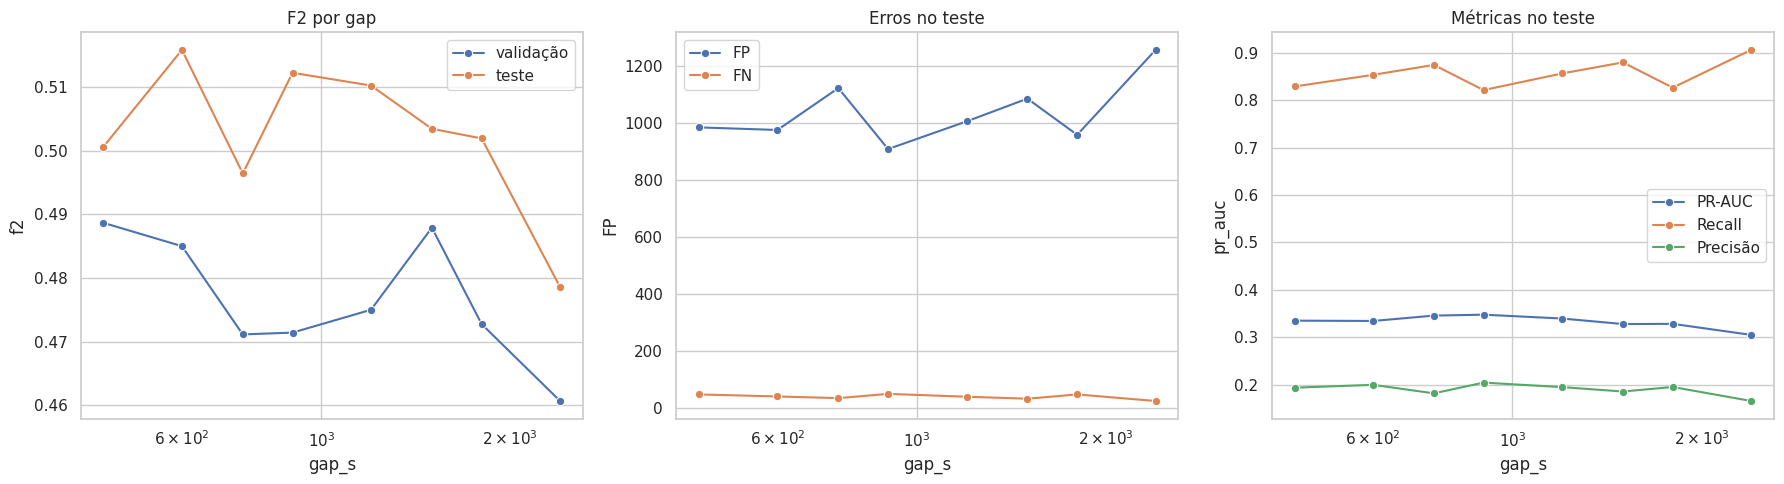

In [5]:
validation_ranking = (
    metrics[metrics["split"] == "validacao"]
    .sort_values(["f2", "precision", "gap_s"], ascending=[False, False, True])
    .copy()
)
test_ranking = metrics[metrics["split"] == "teste"].sort_values("f2", ascending=False).copy()

display(validation_ranking[[
    "gap_s", "threshold", "positivas", "pr_auc", "precision", "recall", "f2",
    "TP", "FP", "FN", "TN", "tempo_s"
]])
display(test_ranking[[
    "gap_s", "threshold", "positivas", "pr_auc", "precision", "recall", "f2",
    "TP", "FP", "FN", "TN", "tempo_s"
]])

chosen_gap = int(validation_ranking.iloc[0]["gap_s"])
chosen_test = metrics[(metrics["split"] == "teste") & (metrics["gap_s"] == chosen_gap)].iloc[0]
print(f"Gap escolhido pela validação: {chosen_gap}s")
print("Resultado correspondente no teste:")
display(chosen_test.to_frame().T)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
test = metrics[metrics["split"] == "teste"].copy()
val = metrics[metrics["split"] == "validacao"].copy()
sns.lineplot(data=val, x="gap_s", y="f2", marker="o", ax=axes[0], label="validação")
sns.lineplot(data=test, x="gap_s", y="f2", marker="o", ax=axes[0], label="teste")
axes[0].set(title="F2 por gap", xscale="log")
sns.lineplot(data=test, x="gap_s", y="FP", marker="o", ax=axes[1], label="FP")
sns.lineplot(data=test, x="gap_s", y="FN", marker="o", ax=axes[1], label="FN")
axes[1].set(title="Erros no teste", xscale="log")
sns.lineplot(data=test, x="gap_s", y="pr_auc", marker="o", ax=axes[2], label="PR-AUC")
sns.lineplot(data=test, x="gap_s", y="recall", marker="o", ax=axes[2], label="Recall")
sns.lineplot(data=test, x="gap_s", y="precision", marker="o", ax=axes[2], label="Precisão")
axes[2].set(title="Métricas no teste", xscale="log")
plt.tight_layout()
plt.show()

## 5. Leitura auditada

Critérios:

- se o gap escolhido pela validação também for competitivo no teste, congelar esse gap para a próxima
  rodada;
- se houver diferença pequena entre gaps vizinhos, preferir a opção com menos FP e comportamento mais
  estável;
- se o melhor gap no teste não for o escolhido pela validação, não trocar automaticamente: isso seria
  ajuste ao teste.

Próxima etapa esperada:

1. reavaliar `IDs + conceitos textuais` com janela 24h/8h e gap escolhido;
2. comparar contra famílias manuais;
3. repetir auditoria de erros.